# Mutation profiles at unbound motif sites

This notebook examines mutation profiles at genomic motif occurrences without detectable ChIP-seq binding.

Whole-genome motif sites were obtained from the JASPAR hg19 tracks (http://expdata.cmmt.ubc.ca/JASPAR/downloads/UCSC_tracks/2022/hg19/).

For each TF, we removed motif sites overlapping the corresponding HepG2 ChIP-seq binding regions to obtain a set of unbound motif sites. A matched number of unbound sites was then selected for comparison with the corresponding bound TFBS.

The analysis includes:

1. Loading whole-genome JASPAR motif sites.
2. Selecting prioritised TFs (17) with available motif sites.
3. Removing motif sites overlapping the corresponding ChIP-seq binding regions.
4. Selecting matched unbound motif sites.
5. Constructing 2,001-bp windows centred on the unbound motifs.
6. Calculating observed and expected PCAWG Liver-HCC mutation profiles along with fold changes and significance.

The resulting profiles are used as controls for the mutation enrichment observed at bound TFBS.


In [1]:
#libraries
import numpy as np
from numpy.polynomial import polynomial as poly
import pandas as pd
import pybedtools as pbt
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats
from bgreference import hg19

from pathlib import Path
from collections import defaultdict
from datetime import datetime

import math, gzip
import statsmodels.stats.multitest

#### File paths

In [ ]:
def find_repo_root():
    "'repository root'"
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if (path / "notebooks").exists() and (path / "results").exists():
            return path

    raise FileNotFoundError("Could not locate repository root.")

REPO_ROOT = find_repo_root()

In [2]:
TFBS_156_FILE = (REPO_ROOT/ "results"/ "preprocessing"/ "TFBS_156_nonoverlapping_sites.tsv")

WG_MOTIF_FILE = (REPO_ROOT/ "data"/ "raw"/ "motifs"/ "wg_motif_regions_filtered_for_chipSites_90_nonSub.csv")

PCAWG_MUTATION_FILE = (REPO_ROOT/ "data"/ "raw"/ "pcawg"/ "PCAWG_Liver-HCC_SBS.bed.gz")

MUT_PROB_FILE = (REPO_ROOT/ "results"/ "preprocessing"/ "PCAWG_trinucleotide_mutation_probabilities.csv")

OUTPUT_DIR = REPO_ROOT / "results" / "Figure1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

UNBOUND_SITES_FILE = (OUTPUT_DIR/ "PCAWG_unbound_motif_control_sites.csv")

In [3]:
TFBS_df = pd.read_csv(TFBS_156_FILE,sep="\t")

TFBS_df = TFBS_df[["Chrom","ChromStart","ChromEnd","Gene","Site length"]].copy()
TFBS_df.columns = range(TFBS_df.shape[1])
TFBS_df.sort_values(by=[3,0,1,2,4], inplace=True)

print("Number of TFBS datasets:", TFBS_df[3].nunique())
TFBS_df.head()

Number of TFBS datasets: 156


,0,1,2,3,4
0,chr1,1310515,1310891,ARID3A,376
1,chr1,1790671,1791047,ARID3A,376
2,chr1,3031848,3032224,ARID3A,376
3,chr1,3251966,3252342,ARID3A,376
4,chr1,4327409,4327785,ARID3A,376


#### read motif files

In [57]:
filtered_wgmotif_sites = pl.scan_csv(WG_MOTIF_FILE,separator="\t")

#### As this is huge, we shall look at motif regions of significant TFs

In [6]:
sig_tfs = ["ARID3A","CTCF","HNF1A","KDM6A","MBD1",
    "MIXL1","NFIA","NFIC","RREB1","TBL1XR1",
    "ZNF143","ZNF511","CEBPA","CEBPB","CEBPG", "SMC3", "RAD21"]

print("Number of TFs:", len(sig_tfs))

Number of TFs: 17


In [8]:
subset_pd = (filtered_wgmotif_sites.filter(pl.col("Gene").is_in(sig_tfs))
    .collect(streaming=True).to_pandas())

print("Number of TFs:", subset_pd["Gene"].nunique())
subset_pd.head()

/tmp/ipykernel_704707/20595448.py:2: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  filtered_wgmotif_sites


Number of TFs: 10


,Chrom,ChromStart,ChromEnd,Gene,Score,pvalue,Strand,motif
0,chr1,11536,11551,HNF1A,817,351,+,MA0046.2.tsv.gz
1,chr1,14412,14427,HNF1A,808,337,-,MA0046.2.tsv.gz
2,chr1,14416,14431,HNF1A,806,335,-,MA0046.2.tsv.gz
3,chr1,20083,20098,HNF1A,823,361,+,MA0046.2.tsv.gz
4,chr1,22368,22383,HNF1A,870,443,-,MA0046.2.tsv.gz


### Subtracting the ChIP sites from the motif sites for each TF.

In [15]:
sites = []

for gene in subset_pd["Gene"].unique().tolist():
    df1 = subset_pd[subset_pd["Gene"] == gene]
    for motif in df1["motif"].unique().tolist():
        df_motif = df1[df1["motif"] == motif]
        df_filtered = TFBS_df[TFBS_df[3] == gene]

        #motif
        motif_bed = pbt.BedTool.from_dataframe(df_motif)
    
        #filtered
        filtered_bed = pbt.BedTool.from_dataframe(df_filtered)
    
        #subtract - A parameter removes the whole feature instead of just subtracting
        unbound_bed = motif_bed.subtract(filtered_bed, A = True)
    
        unbound = unbound_bed.to_dataframe(header=None)
        
        # randomly sample the same number of filtered sites from the unbound sites
        if len(unbound) > len(df_filtered):
            unbound = unbound.sample(n=len(df_filtered)) #random - can set seed
        else:
            pass
        
        # add all the values to sites
        sites.append(unbound)
    
#conveting it into a single dataframe
unbound_sites = pd.concat(sites)
unbound_sites.sort_values(by= ["name", "chrom", "start", "end"], inplace = True)
unbound_sites.reset_index(drop = True, inplace = True)
unbound_sites

,chrom,start,end,name,score,strand,thickStart,thickEnd
0,chr1,330511,330525,CEBPA,830,361,+,MA0102.4.tsv.gz
1,chr1,429326,429340,CEBPA,826,355,-,MA0102.4.tsv.gz
2,chr1,759364,759378,CEBPA,844,382,-,MA0102.4.tsv.gz
3,chr1,993284,993298,CEBPA,827,357,-,MA0102.4.tsv.gz
4,chr1,1039421,1039435,CEBPA,833,364,-,MA0102.4.tsv.gz
...,...,...,...,...,...,...,...,...
284618,chrY,28392363,28392379,ZNF143,841,460,+,MA0088.2.tsv.gz
284619,chrY,28401808,28401824,ZNF143,812,408,+,MA0088.2.tsv.gz
284620,chrY,28563501,28563517,ZNF143,810,406,-,MA0088.2.tsv.gz
284621,chrY,28765766,28765782,ZNF143,842,462,-,MA0088.2.tsv.gz


In [16]:

#adding flanks from midpoint of motif
unbound_sites["mid_start"] = (unbound_sites["start"] + unbound_sites["end"])/2
unbound_sites["mid_start"] = unbound_sites.apply(lambda x: math.floor(x['mid_start']), axis=1)

unbound_sites["mid_end"] = unbound_sites["mid_start"] +1

unbound_sites["reg_start"] = unbound_sites["mid_start"]- 1000
unbound_sites["reg_end"] = unbound_sites["mid_end"]+ 1000
unbound_sites["motif_len"] = abs(unbound_sites["start"] - unbound_sites["end"])

# Sorting and checking the length of the window
unbound_sites.sort_values(by = ["name","chrom","reg_start","reg_end","motif_len"], inplace = True)
unbound_sites["flanks"] = unbound_sites["reg_end"] - unbound_sites["reg_start"]
unbound_sites.reset_index(inplace = True, drop = True)

print(len(unbound_sites))
unbound_sites.head()



284623


,chrom,start,end,name,score,strand,thickStart,thickEnd,mid_start,mid_end,reg_start,reg_end,motif_len,flanks
0,chr1,330511,330525,CEBPA,830,361,+,MA0102.4.tsv.gz,330518,330519,329518,331519,14,2001
1,chr1,429326,429340,CEBPA,826,355,-,MA0102.4.tsv.gz,429333,429334,428333,430334,14,2001
2,chr1,759364,759378,CEBPA,844,382,-,MA0102.4.tsv.gz,759371,759372,758371,760372,14,2001
3,chr1,993284,993298,CEBPA,827,357,-,MA0102.4.tsv.gz,993291,993292,992291,994292,14,2001
4,chr1,1039421,1039435,CEBPA,833,364,-,MA0102.4.tsv.gz,1039428,1039429,1038428,1040429,14,2001


In [17]:
unbound_sites.to_csv(UNBOUND_SITES_FILE,sep="\t",index=False)

In [10]:
unbound_sites = unbound_sites[['chrom','reg_start', 'reg_end','score', 'thickStart', 'motif_len', 'name', 'thickEnd']]
unbound_sites.columns = range(unbound_sites.shape[1])
print(len(unbound_sites))
print(unbound_sites[7].nunique())
print(unbound_sites[6].nunique())
unbound_sites.head()

284623
14
10


,0,1,2,3,4,5,6,7
0,chr1,329518,331519,830,+,14,CEBPA,MA0102.4.tsv.gz
1,chr1,428333,430334,826,-,14,CEBPA,MA0102.4.tsv.gz
2,chr1,758371,760372,844,-,14,CEBPA,MA0102.4.tsv.gz
3,chr1,992291,994292,827,-,14,CEBPA,MA0102.4.tsv.gz
4,chr1,1038428,1040429,833,-,14,CEBPA,MA0102.4.tsv.gz


In [ ]:
unbound_sites = unbound_sites[unbound_sites[1] >= 0]

In [ ]:
#cleanup

In [13]:
woMotif = unbound_sites[[0,1,2,5,7,6]]
woMotif.columns = range(woMotif.shape[1])
print(woMotif[(4)].unique())
woMotif.head()

['MA0102.4.tsv.gz' 'MA0466.3.tsv.gz' 'MA1636.1.tsv.gz' 'MA0838.1.tsv.gz'
 'MA1929.1.tsv.gz' 'MA0139.1.tsv.gz' 'MA1930.1.tsv.gz' 'MA0046.2.tsv.gz'
 'MA0662.1.tsv.gz' 'MA0670.1.tsv.gz' 'MA0161.2.tsv.gz' 'MA1527.1.tsv.gz'
 'MA0073.1.tsv.gz' 'MA0088.2.tsv.gz']


,0,1,2,3,4,5
0,chr1,329518,331519,14,MA0102.4.tsv.gz,CEBPA
1,chr1,428333,430334,14,MA0102.4.tsv.gz,CEBPA
2,chr1,758371,760372,14,MA0102.4.tsv.gz,CEBPA
3,chr1,992291,994292,14,MA0102.4.tsv.gz,CEBPA
4,chr1,1038428,1040429,14,MA0102.4.tsv.gz,CEBPA


In [29]:
woMotif = woMotif[~woMotif[4].isin(["MA1929.1.tsv.gz", "MA1930.1.tsv.gz", "MA1636.1.tsv.gz", "MA0161.2.tsv.gz"])] # removing multi_motifs
woMotif[(4)].unique()


array(['MA0102.4.tsv.gz', 'MA0466.3.tsv.gz', 'MA0838.1.tsv.gz',
       'MA0139.1.tsv.gz', 'MA0046.2.tsv.gz', 'MA0662.1.tsv.gz',
       'MA0670.1.tsv.gz', 'MA1527.1.tsv.gz', 'MA0073.1.tsv.gz',
       'MA0088.2.tsv.gz'], dtype=object)

#### SBS - Liver PCAWG

In [14]:
HCC_subs = pd.read_csv(PCAWG_MUTATION_FILE, sep="\t",header=None)

HCC_subs.rename(columns={0:"Chrom",
        1:"ChromStart",2:"ChromEnd", 3:"Nt", 4:"Subs_Nt", 5:"Code", 6:"Type"},inplace=True)
HCC_nbp = HCC_subs[["Chrom","ChromStart","ChromEnd"]].copy()

print("Number of samples:", HCC_subs["Code"].nunique())
HCC_nbp.head()

Number of samples: 314


,Chrom,ChromStart,ChromEnd
0,chr1,10505,10506
1,chr1,20251,20252
2,chr1,77903,77904
3,chr1,94993,94994
4,chr1,121080,121081


##### Mut probs

In [15]:
mut_prob = pd.read_csv(MUT_PROB_FILE, sep="\t")
mut_prob.head()

,mutation,Probability_PCAWG_all_samples,Probability_PCAWG_8_outliers,Probability_PCAWG_wo8_outliers,Probability_nfia_top3_outliers,Probability_nfia_13_outliers,Probability_nfia_wotop3_outliers,Probability_nfia_wo13_outliers
0,"('AAA', 'ACA')",0.001757,0.001610,0.001770,0.007259,0.002493,0.001662,0.001677
1,"('AAA', 'ATA')",0.002032,0.002242,0.002014,0.002116,0.001859,0.002030,0.002051
2,"('AAA', 'AGA')",0.003734,0.003977,0.003713,0.003169,0.003882,0.003744,0.003718
3,"('AAC', 'ACC')",0.001318,0.001225,0.001326,0.004118,0.001778,0.001269,0.001268
4,"('AAC', 'ATC')",0.002091,0.002279,0.002076,0.002471,0.001962,0.002085,0.002106


##### Mutation Profiles

In [30]:
# function to compute the expected mutation counts
def get_exp_mut(res_df, flank, sign_dict, gene, ttype):
    '''compute the expected mutation count'''
    
    # exp counts
    nucleotides = set(['A', 'T', 'C', 'G'])

    final_position_prob_df = pd.DataFrame()
    final_position_prob_norm = pd.DataFrame()
    
    fasta = {}
    

    for idx, g in res_df.groupby([0, 1, 2]):

        chrm = g[0].values[0]
        chrStart = g[1].values[0]
        chrEnd = g[2].values[0]
        #gene = g[5].values[0]
        totalMuts = g[9].sum() # total obs mutations mapped to this region

        if totalMuts == 0: # skip the following if the segment has no mutation
            continue

        # extract the subsequence 
        # using bgreference
        #fasta sequences based on the cordinate for each TFBS
        tkey = "%s:%s-%s" % (chrm, chrStart, chrEnd)
        subseq = hg19(chrm, chrStart, (int(chrEnd)-int(chrStart))+2)
        fasta[tkey] = subseq

                           
        if len(fasta) == 0:
            print(tkey)
            
        start = -flank
        position_prob_lol = list()

        for i in range(1, len(subseq)-1):
            my_trinucleotide = subseq[i-1:i+2]
            # if i < max_prints:
            #     print(my_trinucleotide)
            my_ref_base = my_trinucleotide[1].upper()
            my_alt_bases = nucleotides - set(my_ref_base)
            my_base_probs = 0
            previous_base = my_trinucleotide[0]
            next_base = my_trinucleotide[2]

            for alt_base in my_alt_bases:
                tri_ref = previous_base + str(my_ref_base) + next_base
                tri_alt = previous_base + str(alt_base) + next_base
                my_key = str((tri_ref, tri_alt))

                try:
                    my_prob = sign_dict[my_key][ttype]
                    my_base_probs = my_base_probs + my_prob

                except:
                    None

           
            # if i < max_prints:
            #     print(tri_ref, tri_alt)


            position_prob_lol.append([start, my_base_probs])
            start += 1

        position_prob_df = pd.DataFrame(position_prob_lol)
        position_prob_df.columns = ['position', 'probability']
        
        #for normalised values
        position_prob_norm = pd.DataFrame(position_prob_lol)
        position_prob_norm.columns = ['position', 'probability']

        my_total = sum(position_prob_df['probability'])
        
        
        position_prob_df['probability'] = position_prob_df['probability']/my_total
        position_prob_df['expected_muts'] = position_prob_df['probability']*int(totalMuts)
          
        position_prob_df = position_prob_df[['position', 'expected_muts']]

        # Sum the expected results (i.e., the output from each sequence)
        if len(final_position_prob_df) == 0:
            final_position_prob_df = position_prob_df
        else:
            final_position_prob_df['expected_muts'] = (final_position_prob_df['expected_muts'] +
                                                           position_prob_df['expected_muts'])
    
    return final_position_prob_df 



In [31]:
def fisherstest(df, motif, core, dhs, flank):
    '''function to perform Fisher's exact test'''
    #Step: computing mutations for obs and expected
    obs_muts_motif = df[(df['position']>=-motif) & (df['position']<=motif)]['observed_muts'].sum()
    obs_muts_core = df[(df['position']>=-core) & (df['position']<=core)]['observed_muts'].sum()
    obs_muts_dhs = df[(df['position']<-core) & (df['position']>-dhs)]['observed_muts'].sum() + df[(df['position']>core) & (df['position']<dhs)]['observed_muts'].sum()
    obs_muts_flank = df[(df['position']<-dhs) & (df['position']>-flank)]['observed_muts'].sum() + df[(df['position']>dhs) & (df['position']<flank)]['observed_muts'].sum()
    obs_motif_flank = df[(df['position']<-motif)]['observed_muts'].sum() + df[(df['position']>motif)]['observed_muts'].sum()
    obs_core_flank = df[(df['position']<-core)]['observed_muts'].sum() + df[(df['position']>core)]['observed_muts'].sum()
#    tot_obs = obs_muts_motif + obs_muts_core + obs_muts_dhs + obs_muts_flank
    
    exp_muts_motif = df[(df['position']>=-motif) & (df['position']<=motif)]['expected_muts'].sum()
    exp_muts_core = df[(df['position']>=-core) & (df['position']<=core)]['expected_muts'].sum()
    exp_muts_dhs = df[(df['position']<-core) & (df['position']>-dhs)]['expected_muts'].sum() + df[(df['position']>core) & (df['position']<dhs)]['expected_muts'].sum()
    exp_muts_flank = df[(df['position']<-dhs) & (df['position']>-flank)]['expected_muts'].sum() + df[(df['position']>dhs) & (df['position']<flank)]['expected_muts'].sum()
    exp_motif_flank = df[(df['position']<-motif)]['expected_muts'].sum() + df[(df['position']>motif)]['expected_muts'].sum()
    exp_core_flank = df[(df['position']<-core)]['expected_muts'].sum() + df[(df['position']>core)]['expected_muts'].sum()
 #   tot_exp = exp_muts_motif + exp_muts_core + exp_muts_dhs + exp_muts_flank

   # print(obs_muts_core, exp_muts_core, obs_core_flank, exp_core_flank)
    
    #contigency table core
    cont_core = [[obs_muts_core, exp_muts_core],
        [obs_core_flank, exp_core_flank]]
    odd_ratio_core, p_value_core = stats.fisher_exact(cont_core, alternative = 'two-sided')

    #contigency table motif
    cont_motif = [[obs_muts_motif, exp_muts_motif],
        [obs_motif_flank, exp_motif_flank]]
    odd_ratio_motif, p_value_motif = stats.fisher_exact(cont_motif, alternative = 'two-sided')

    
   
    #Step: computing Fc
    fc_motif = obs_muts_motif/exp_muts_motif
    fc_core = obs_muts_core/exp_muts_core
    fc_dhs = obs_muts_dhs/exp_muts_dhs
    fc_flanks = obs_muts_flank/exp_muts_flank
    
    print(f"FC_core: {fc_core}", f"OR_core{odd_ratio_core}", f"Pvalue_core: {p_value_core}", '\n'
         f"FC_motif: {fc_motif}", f"OR_motif{odd_ratio_motif}", f"Pvalue_motif: {p_value_motif}")
    
    return(obs_muts_motif, obs_muts_core, obs_motif_flank, obs_core_flank, exp_muts_motif, exp_muts_core, exp_motif_flank, exp_core_flank, fc_motif, fc_core, fc_dhs, fc_flanks, odd_ratio_motif, p_value_motif, odd_ratio_core, p_value_core)

In [32]:
def format_fc_p(fc, p, tiny_thresh=1e-4, sci_thresh=1e-3):
    """Formatting: so that very low p values do not look like 0.00000 
       - p < 1e-4  -> threshold form
       - 1e-4 ≤ p < 1e-3 -> scientific notation (avoids 0.000) 
       - p ≥ 1e-3 -> fixed 3 decimals
    """
    if p < tiny_thresh:
        return f"FC={fc:.2f}, p<{tiny_thresh:.0e}"   
    elif p < sci_thresh:
        return f"FC={fc:.2f}, p={p:.1e}"            
    else:
        return f"FC={fc:.2f}, p={p:.3f}"            

/tmp/ipykernel_704707/3191425224.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Motif: CEBPA TFBS:CEBPA Obs Sum: 130276 Exp Sum: 130276.0000000005
FC_core: 1.0378200537649698 OR_core1.0400379269498015 Pvalue_core: 0.028299100979957886 
FC_motif: 1.109451109872015 OR_motif1.110918833675281 Pvalue_motif: 0.02120352512805439
FC motif:1.109451109872015 Pvalue motif: 0.02120352512805439
FC core:1.0378200537649698 Pvalue: 0.028299100979957886


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


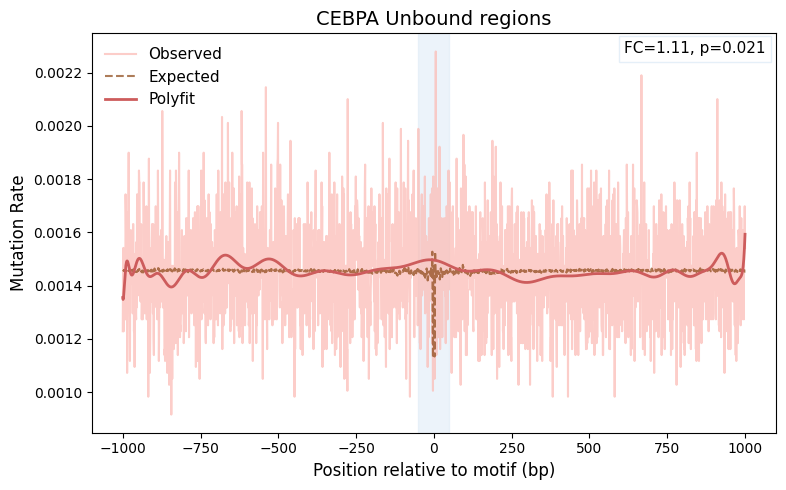

/tmp/ipykernel_704707/3191425224.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Motif: CEBPB TFBS:CEBPB Obs Sum: 79151 Exp Sum: 79151.00000000019
FC_core: 1.0107459536841945 OR_core1.0113259427816357 Pvalue_core: 0.6305798248013952 
FC_motif: 1.0670184509071794 OR_motif1.0687869791767775 Pvalue_motif: 0.287419935652268
FC motif:1.0670184509071794 Pvalue motif: 0.287419935652268
FC core:1.0107459536841945 Pvalue: 0.6305798248013952


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


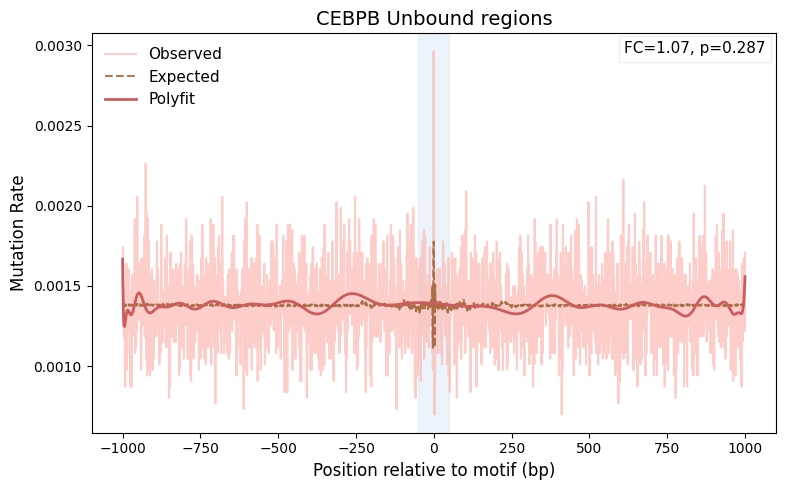

/tmp/ipykernel_704707/3191425224.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Motif: CEBPG TFBS:CEBPG Obs Sum: 95429 Exp Sum: 95429.0000000004
FC_core: 1.0101054013269564 OR_core1.0107479069006668 Pvalue_core: 0.6159565820668575 
FC_motif: 1.0726028669179168 OR_motif1.0750002201935482 Pvalue_motif: 0.24728926410288904
FC motif:1.0726028669179168 Pvalue motif: 0.24728926410288904
FC core:1.0101054013269564 Pvalue: 0.6159565820668575


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


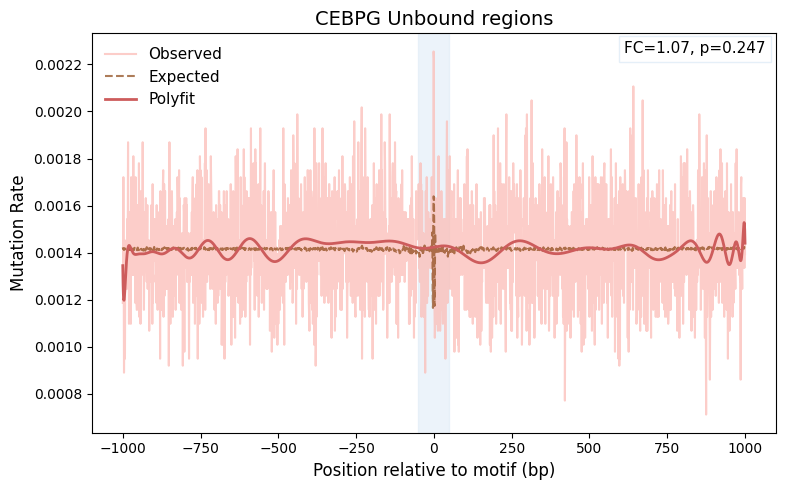

/tmp/ipykernel_704707/3191425224.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Motif: CTCF TFBS:CTCF Obs Sum: 109502 Exp Sum: 109502.00000000044
FC_core: 0.9847912133565153 OR_core0.9840982124984182 Pvalue_core: 0.40932001609665836 
FC_motif: 0.9206663421556369 OR_motif0.9207114487683856 Pvalue_motif: 0.061089522082251595
FC motif:0.9206663421556369 Pvalue motif: 0.061089522082251595
FC core:0.9847912133565153 Pvalue: 0.40932001609665836


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


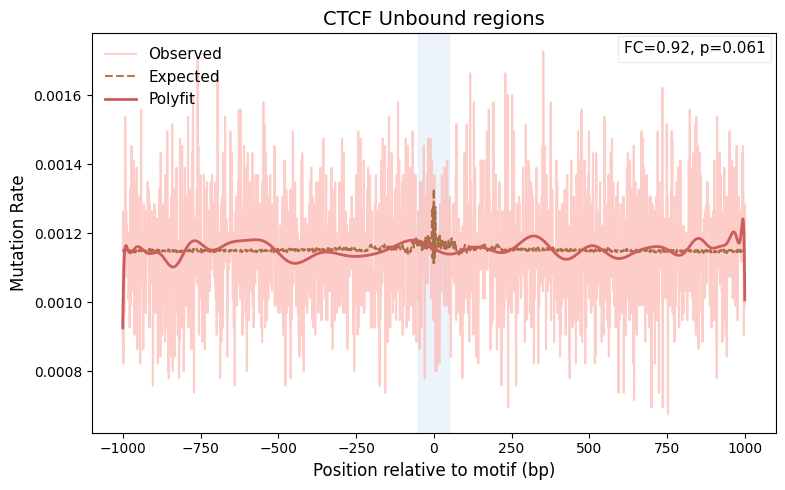

/tmp/ipykernel_704707/3191425224.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Motif: HNF1A TFBS:HNF1A Obs Sum: 24593 Exp Sum: 24593.000000000095
FC_core: 1.1334724204268676 OR_core1.1414090011185964 Pvalue_core: 0.0011044224857548728 
FC_motif: 1.1150375455807546 OR_motif1.1216083285515206 Pvalue_motif: 0.2959736966974259
FC motif:1.1150375455807546 Pvalue motif: 0.2959736966974259
FC core:1.1334724204268676 Pvalue: 0.0011044224857548728


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


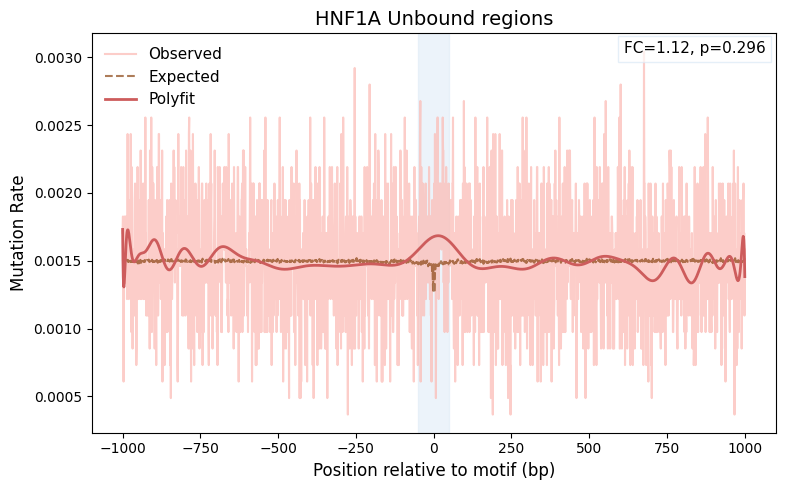

/tmp/ipykernel_704707/3191425224.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Motif: MIXL1 TFBS:MIXL1 Obs Sum: 51112 Exp Sum: 51112.00000000021
FC_core: 0.9947043352441745 OR_core0.9946152160092034 Pvalue_core: 0.8516915806922832 
FC_motif: 0.9791572519704924 OR_motif0.9812968339490128 Pvalue_motif: 0.8282812027564974
FC motif:0.9791572519704924 Pvalue motif: 0.8282812027564974
FC core:0.9947043352441745 Pvalue: 0.8516915806922832


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


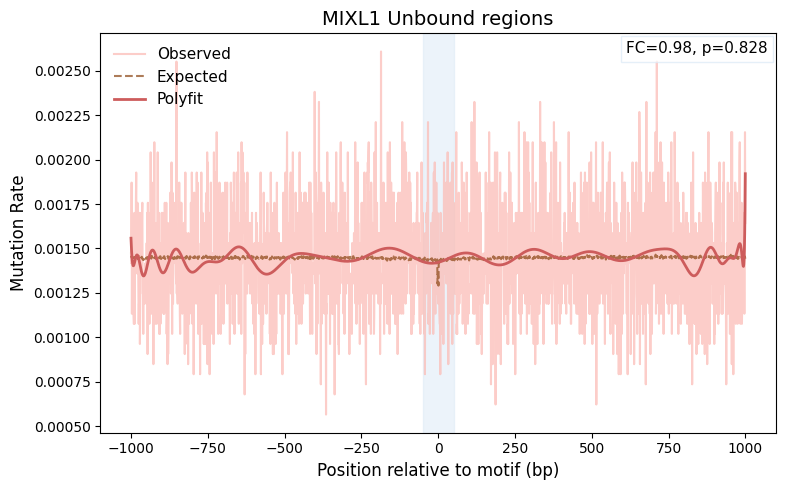

/tmp/ipykernel_704707/3191425224.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Motif: NFIA TFBS:NFIA Obs Sum: 43572 Exp Sum: 43572.000000000146
FC_core: 1.0118472966922236 OR_core1.0124622314537988 Pvalue_core: 0.6993534816097572 
FC_motif: 0.9294392071412829 OR_motif0.9318378367389067 Pvalue_motif: 0.4530384554965374
FC motif:0.9294392071412829 Pvalue motif: 0.4530384554965374
FC core:1.0118472966922236 Pvalue: 0.6993534816097572


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


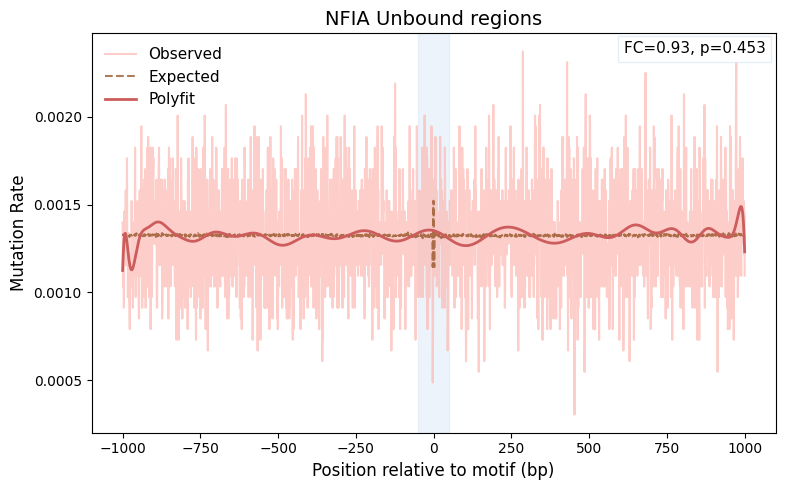

/tmp/ipykernel_704707/3191425224.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Motif: NFIC TFBS:NFIC Obs Sum: 22014 Exp Sum: 22014.00000000006
FC_core: 1.0285534048226619 OR_core1.0307058393997421 Pvalue_core: 0.4930174906958512 
FC_motif: 1.0618251412242379 OR_motif1.0633632436296494 Pvalue_motif: 0.5778088711091305
FC motif:1.0618251412242379 Pvalue motif: 0.5778088711091305
FC core:1.0285534048226619 Pvalue: 0.4930174906958512


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


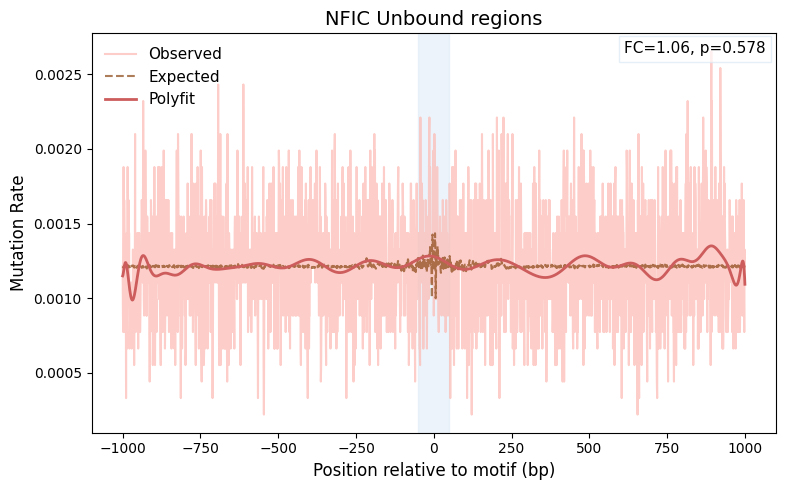

/tmp/ipykernel_704707/3191425224.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Motif: RREB1 TFBS:RREB1 Obs Sum: 22784 Exp Sum: 22784.000000000055
FC_core: 0.8130207479066115 OR_core0.80548623142094 Pvalue_core: 1.4624878616967014e-06 
FC_motif: 0.8740093011228576 OR_motif0.875430988177156 Pvalue_motif: 0.16563575675340697
FC motif:0.8740093011228576 Pvalue motif: 0.16563575675340697
FC core:0.8130207479066115 Pvalue: 1.4624878616967014e-06


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


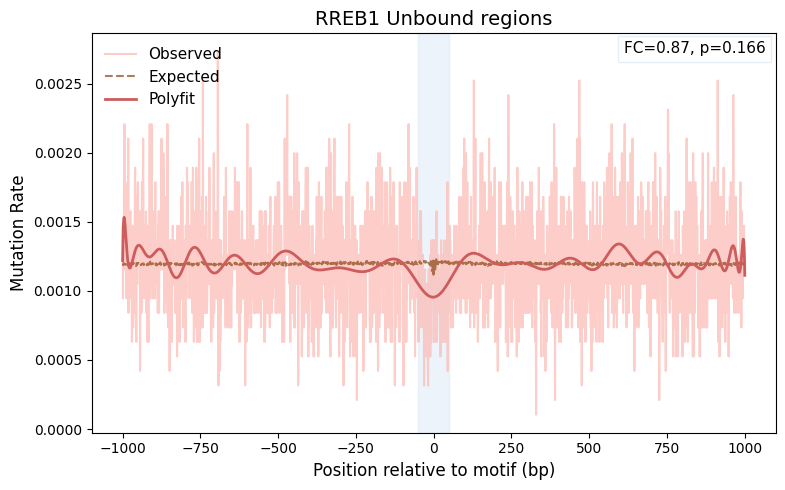

/tmp/ipykernel_704707/3191425224.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Motif: ZNF143 TFBS:ZNF143 Obs Sum: 42759 Exp Sum: 42759.00000000014
FC_core: 1.0281232482136986 OR_core1.0300671071644414 Pvalue_core: 0.34557544531782347 
FC_motif: 1.068084859065108 OR_motif1.0699644616522657 Pvalue_motif: 0.36730689749479833
FC motif:1.068084859065108 Pvalue motif: 0.36730689749479833
FC core:1.0281232482136986 Pvalue: 0.34557544531782347


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


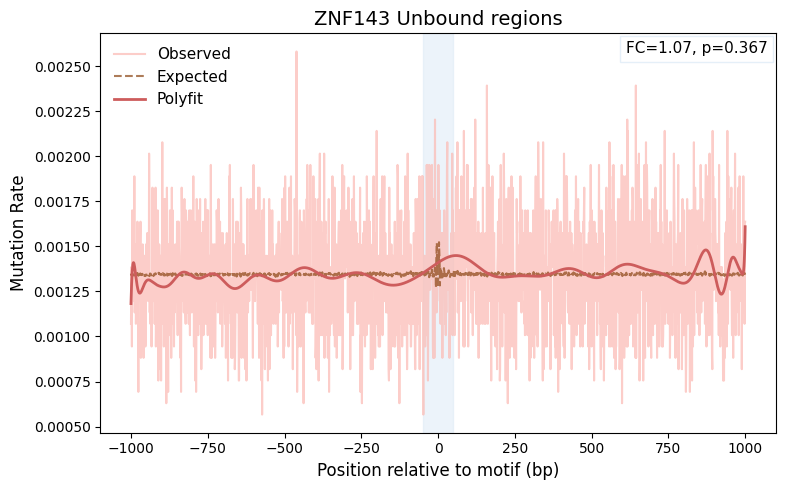

Duration: 0:27:26.856125


In [33]:
from datetime import datetime
start_time = datetime.now()

core = 50
dhs = 250
flank_size = 1000

for tumor_type in ['PCAWG_all_samples']:
    
    # read signature probabilities
    sign_dict = mut_prob.set_index('mutation').T.to_dict()
    
    
    HCCnbp_bed = pbt.BedTool.from_dataframe(HCC_nbp)
    
    #creating a list for the plot_values later on
    plot_values = []
    plot_values_normalised = []
    pos_muts = pd.DataFrame()
    pos_muts_normalised = pd.DataFrame()
    p_value = []
    
    for gene in woMotif[5].unique().tolist():
        #to get a list of all the (unique)genes presnt in the dataframe
        #adding the unique gene list to a df
        df2=woMotif[woMotif[5]== gene]
        tfbs = df2[5].iloc[0]
        #df2_len = (len(df2)) 
        
        df2_bed = pbt.BedTool.from_dataframe(df2)
        #saving the value of length of the motif
        motif = math.floor((df2[3].unique())/2)
        pfm = df2[5].iloc[0]
    
        # intersect mutations with the TFBS region
        res1 = df2_bed.intersect(HCCnbp_bed, wo=True)
        res_df = res1.to_dataframe(header=None)
        res_df.columns = range(res_df.shape[1])
        res = pbt.BedTool.from_dataframe(res_df)
        #print(res_df)
                              
        obs_counts = defaultdict(int)
        for row in res:
            middle = int(row[2])-flank_size
            diff = int(row[8])-middle
            obs_counts[diff] += 1
    
        collect = []
        for i in range(-flank_size, flank_size+1, 1):
            if i in obs_counts.keys():
                collect.append([i, obs_counts[i]])
            else:
                collect.append([i, 0])

        obs_df = pd.DataFrame(collect, columns=['position', 'observed_muts'])
        obs_norm = obs_df.copy()
        obs_norm['observed_muts'] = obs_norm['observed_muts']/len(df2) 

#       get expected mutation count
        final_position_prob_df = get_exp_mut(res_df, flank_size, sign_dict, gene, "Probability_%s" % tumor_type)
        
        final_position_prob_norm = final_position_prob_df.copy()
        final_position_prob_norm['expected_muts'] = final_position_prob_df['expected_muts']/len(df2)
    
        print(
            f"Samples: {tumor_type}",
            f"Motif: {gene}",
            f"TFBS:{tfbs}",
            f"Obs Sum: {obs_df['observed_muts'].sum()}",
            f"Exp Sum: {final_position_prob_df['expected_muts'].sum()}"
        )
            
        to_plot = pd.merge(obs_df, final_position_prob_df, on='position')
        to_plot["motif"] = gene
        to_plot["TFBS"] = tfbs
        to_plot_normalised = pd.merge(obs_norm, final_position_prob_norm, on='position')
        to_plot_normalised["motif"] = gene
        to_plot_normalised["TFBS"] = tfbs
        

        
        # Append the modified DataFrame to the list
        plot_values.append(to_plot)
        plot_values_normalised.append(to_plot_normalised)

        # Concatenate all the DataFrames in the list into one DataFrame
        pos_muts = pd.concat(plot_values, ignore_index=True)
        pos_muts_normalised = pd.concat(plot_values_normalised, ignore_index=True)
        
    
        # Fishers-test to find out if the number of mutations at the core is more than expected
        obs_motif, obs_muts, obs_motif_flank, obs_flank_muts, exp_motif, exp_muts, exp_motif_flank, exp_flank_muts, fc_motif, fc_core, fc_dhs, fc_flanks, odd_ratio_motif, p_value_motif, odd_ratio_core, p_value_core = fisherstest(to_plot, motif, core, dhs, flank_size)
        # adding all observed and expected values to a df
        p_value.append([tfbs, gene, obs_motif, obs_muts, obs_motif_flank, 
                        obs_flank_muts, exp_motif, exp_muts, exp_motif_flank, 
                        exp_flank_muts, fc_motif, fc_core, fc_dhs, fc_flanks, 
                        odd_ratio_motif, p_value_motif, odd_ratio_core, p_value_core])
        p_value_df = pd.DataFrame(p_value)
        p_value_df.columns = ["TFBS", "Motif", "Obs_motif", "Obs_core101", "Obs_motif_flank", "Obs_flank", 
                              "Exp_motif", "Exp_core101", "Exp_motif_flank", "Exp_flank", 
                              "FC_motif", "FC_50", "FC_dhs(250)", "FC_flank", 
                              "OddsRatio_motif", "P-value_motif", "OddsRatio_core", "P-value50"]    
        print(f"FC motif:{fc_motif}", f"Pvalue motif: {p_value_motif}")
        print(f"FC core:{fc_core}", f"Pvalue: {p_value_core}")
        
        #Plots
        fig, ax = plt.subplots(figsize=(8,5))
        # Observed (light pink)
        plt.plot(to_plot_normalised['position'], to_plot_normalised['observed_muts'], color="#fcb9b2", alpha=0.7, label="Observed")
        # Expected (saddle brown dashed)
        plt.plot(to_plot_normalised['position'], to_plot_normalised['expected_muts'], color="saddlebrown", linestyle="--", label="Expected", alpha = 0.7)
        # Highlight core region
        ax.axvspan(-core, core, color="#dbe9f6", alpha=0.5)

        # Asthetics
        #plt.title("%s %s" % (tumor_type, gene))
        #plt.text(0.8, 0.93,'fc='+ str(fc_core)[:4]+' ,P='+"%.3f"%(p_value_core), ha='center', va='center', bbox={'facecolor':'w','pad':5}, transform=plt.gca().transAxes)
        coefs = poly.polyfit(to_plot_normalised['position'], to_plot_normalised['observed_muts'], 50)
        ffit = poly.polyval (to_plot_normalised['position'], coefs)
        plt.plot(to_plot_normalised['position'], ffit,color="indianred", linewidth= 2, zorder=3, label="Polyfit")
        
        # Title + annotation
        ax.set_title(f"{gene} Unbound regions", fontsize=14, )
        ax.set_xlabel("Position relative to motif (bp)", fontsize=12)
        ax.set_ylabel("Mutation Rate", fontsize=12)
        label_text = format_fc_p(fc_motif, p_value_motif, tiny_thresh=1e-4)
        ax.text(
            0.778, 0.98, label_text,
            transform=ax.transAxes, ha="left", va="top",
            fontsize=11, bbox=dict(facecolor="white", alpha=0.7, edgecolor="#dbe9f6")
        )
        ax.legend(loc="upper left", frameon=False, fontsize=11)
        plt.tight_layout()
        plt.show()

      
       # break
        

end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))

In [34]:
p_value_df.to_csv(OUTPUT_DIR / "PCAWG_unbound_motif_mutation_rate_statistics.csv",sep="\t",index=False)
pos_muts.to_csv(OUTPUT_DIR / "PCAWG_unbound_motif_position_mutation_profiles.csv",sep="\t",index=False)

In [35]:
pbt.cleanup()